# Hierarchical classifier workflow

`scpdac` ships a **3-model hierarchical MLP classifier** that annotates an
unlabelled PDAC dataset with fine-grained cell-type labels in a single call to
`scpdac.tl.predict_labels`.

The hierarchy predicts a label in two steps:

1. **Root** — a binary *Malignant* vs *Non-Malignant* classifier is applied to
   every cell.
2. **Sub-classifiers** — each cell is then routed, according to the root call, to
   either the *malignant* or the *non-malignant* fine-grained sub-classifier,
   which assigns the final cell type.

All three models operate on **log-normalised expression** (not binned counts) and
automatically realign your genes to the panel they were trained on, zero-imputing
any that are missing.

In this tutorial we will:

- download a public PDAC dataset ([Chen et al. 2025](https://www.cell.com/cancer-cell/fulltext/S1535-6108(25)00393-9)) to use as the query,
- normalise it the way the classifier expects,
- predict hierarchical labels, and
- sanity-check the annotations on a UMAP and with canonical marker genes.

> **Bring your own data.** The Chen et al. dataset is only an example: replace it
> with your own `AnnData` and skip the download in *Section 1*.
>
> **No atlas download is needed** for the classifier — the trained models ship
> with `scpdac`.

## Setup

We only need the single-cell stack (`scanpy`, `anndata`), `scpdac` itself, and an
approximate-nearest-neighbour transformer to speed up the neighbourhood graph
used for UMAP.

In [9]:
import urllib.request
from pathlib import Path

import pandas as pd
import anndata as ad
import scanpy as sc
import scpdac
from sklearn_ann.kneighbors.annoy import AnnoyTransformer

### Configure paths

The example data is written below `DATA_DIR`; change it to any location you like.

In [ ]:
SPECIES = "human"

DATA_DIR = Path("data")  # <-- change
QUERY_DIR = DATA_DIR / "chen_2025"  # example query, replace with your own data

In [ ]:
def download(url: str, dest: Path) -> Path:
    """Download ``url`` to ``dest`` unless it already exists (safe to re-run)."""
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        print(f"Already present, skipping: {dest}")
        return dest
    tmp = dest.with_name(dest.name + ".part")
    print(f"Downloading {url}\n  -> {dest}")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    return dest

## 1. Download the query data (tutorial only)

We use the [Chen et al. 2025](https://www.cell.com/cancer-cell/fulltext/S1535-6108(25)00393-9)
PDAC cohort (GEO accession `GSE278688`) — 14 samples and roughly 200,000 cells —
as an example query.

> ### ⚠️ Example data only — replace it with your own
>
> The Chen et al. 2025 cohort is used **purely as a worked example**. In a real
> analysis you should **replace it with your own dataset** and skip the download
> below entirely.
>
> **Download size:** ~1.1 GB (mostly `matrix.mtx.gz`). Reading the full matrix
> (~200,000 cells) into memory needs several GB of RAM.

In [ ]:
GEO_URL = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE278688&format=file&file=GSE278688_sc_{}"

for fname in ["features.tsv.gz", "barcodes.tsv.gz", "matrix.mtx.gz", "metadata.csv.gz"]:
    download(GEO_URL.format(fname), QUERY_DIR / fname)

## 2. Load the query dataset

The classifier expects the query to carry **raw counts**. Here we read the 10x
matrix, attach the published cell metadata, and stash the raw counts in a
dedicated layer so later normalisation doesn't overwrite them.

**Using your own data?** Replace the next few cells with a single load of your
`AnnData`, e.g.

```python
query = sc.read_h5ad("path/to/your_data.h5ad")
```

and make sure it has **raw counts** in `layers["counts"]` and a per-sample batch
column in `obs["Sample_ID"]`.

In [4]:
adata = sc.read_10x_mtx(QUERY_DIR)

The published metadata uses `patients` as the sample identifier, so we rename it
to the `Sample_ID` convention used throughout `scpdac`.

In [5]:
cell_metadata = pd.read_csv(QUERY_DIR / "metadata.csv.gz", index_col=0)

In [6]:
cell_metadata = cell_metadata.rename(
    columns={
        "patients": "Sample_ID",
    }
)

In [7]:
adata.obs = cell_metadata
len(adata.obs.Sample_ID.unique())

14

Keep an untouched copy of the raw counts in `layers["counts"]` — we normalise `X`
in place shortly and want the originals preserved.

In [10]:
adata.layers["counts"] = adata.X.copy()

To keep the tutorial fast we subset the query to two patients (`PA01`, `PA02`).
In practice, run on your full cohort — the classifier scales comfortably to
hundreds of thousands of cells.

In [11]:
adata = adata[adata.obs.Sample_ID.isin(["PA01", "PA02"])].copy()

## 3. Predict hierarchical labels

### Normalise and log-transform

The three MLPs were trained on **library-size-normalised, log1p-transformed**
expression, so the query must be preprocessed the same way. We normalise, take
`log1p`, and store the result in `layers["log_norm"]` — the layer we point the
classifier at below.

In [12]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log_norm"] = adata.X.copy()

### Run the classifier

`scpdac.tl.predict_labels` loads the packaged human checkpoints, runs the root
model, routes each cell to the matching fine-grained sub-classifier, and writes
the predictions back into `adata.obs` — all in place. The `layer` argument tells
it where to find the log-normalised expression.

In [13]:
scpdac.tl.predict_labels(adata, species=SPECIES, layer="log_norm")

AnnData object with n_obs × n_vars = 9631 × 30543
    obs: 'tissue', 'Sample_ID', 'all_celltype', 'predicted_malignant', 'predicted_celltype'
    var: 'gene_ids', 'feature_types'
    uns: 'log1p'
    layers: 'counts', 'log_norm'

## 4. Inspect the predictions

The classifier adds two columns to `obs`:

- `predicted_malignant` — the root call (*Malignant* / *Non-Malignant*),
- `predicted_celltype` — the final fine-grained label.

Alongside the uncertainity scores for both.
Cross-tabulating them shows how cells are distributed across the hierarchy.

In [14]:
adata.obs[["predicted_malignant", "predicted_celltype"]].value_counts()

predicted_malignant  predicted_celltype          
Non-Malignant        CD8+ T Cell                     4604
                     CD4+ T Cell                     1569
Malignant            Malignant Cell - Epithelial      623
Non-Malignant        Macrophage                       615
                     Cancer Associated Fibroblast     528
Malignant            Malignant Cell - Mesenchymal     411
Non-Malignant        B Cell                           332
                     NK Cell                          282
                     Endothelial Cell                 243
                     Neutrophil                       175
                     Ductal Cell (atypical)            72
                     Mast Cell                         66
                     Acinar (REG+) Cell                31
                     Plasma Cell                       19
                     Schwann Cell                      13
                     Mixed T Cell                      11
                     D

### Visualise on a UMAP

To eyeball the annotations we build a standard PCA → neighbours → UMAP embedding.
The `AnnoyTransformer` gives an approximate but much faster neighbourhood graph.

In [15]:
sc.pp.pca(adata)
sc.pp.neighbors(adata, transformer=AnnoyTransformer(15))

/environments/daniele/micromamba/envs/atlas_review/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
sc.tl.umap(adata)

In [19]:
adata

AnnData object with n_obs × n_vars = 9631 × 30543
    obs: 'tissue', 'Sample_ID', 'all_celltype', 'predicted_malignant', 'predicted_celltype'
    var: 'gene_ids', 'feature_types'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'predicted_malignant_colors', 'predicted_celltype_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_norm'
    obsp: 'distances', 'connectivities'

Colouring the UMAP by the predicted labels (and by `Sample_ID`) shows whether the
annotations form coherent, well-separated populations rather than tracking batch.

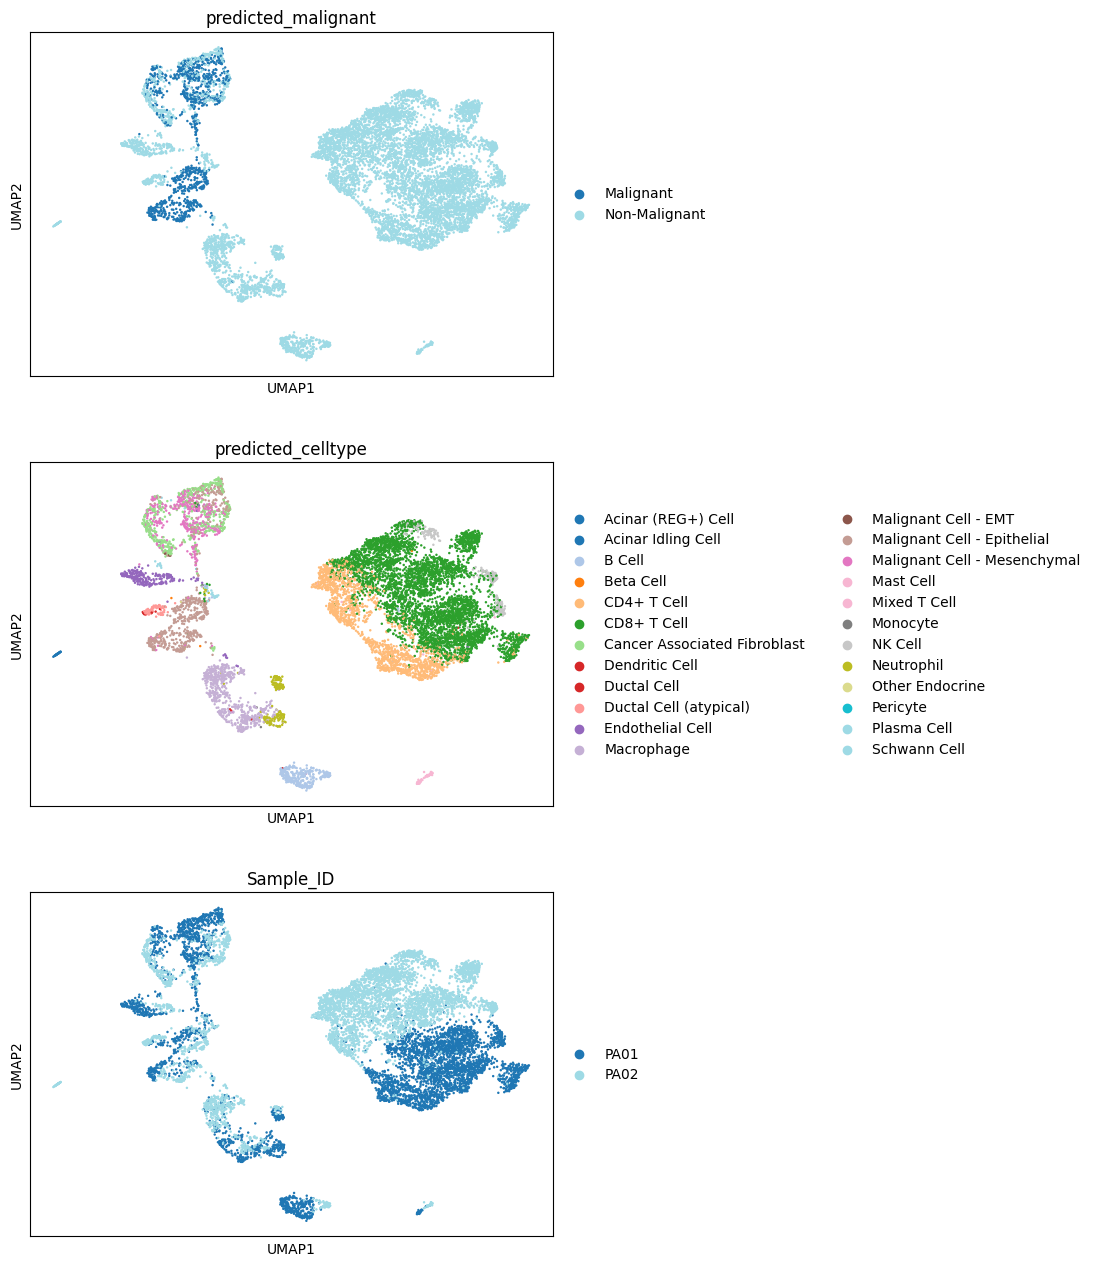

In [26]:
sc.pl.umap(adata, color=["predicted_malignant", "predicted_celltype", "Sample_ID"], palette="tab20", ncols=1)

### Validate with canonical markers

A final sanity check: canonical marker genes should light up in the expected
populations — *CD79A* (B cells), *KRT18* (epithelial / ductal), *S100A8*
(myeloid / neutrophils), *CD8A* (CD8⁺ T cells), and *CDH5* (endothelium).

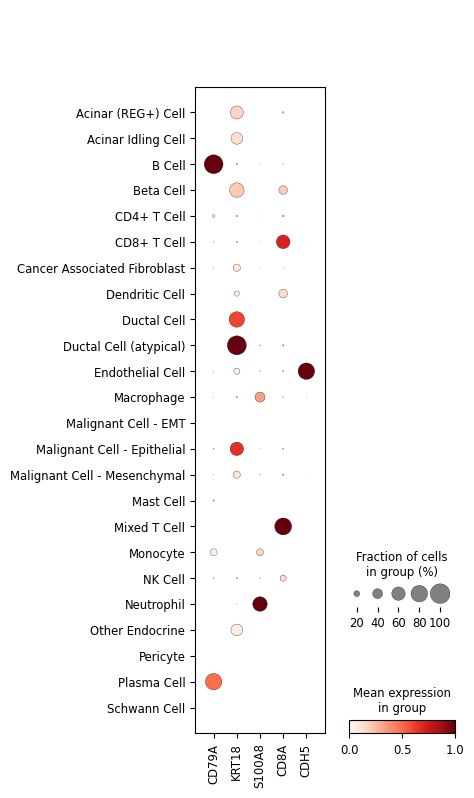

In [29]:
sc.pl.dotplot(
    adata, groupby="predicted_celltype", var_names=["CD79A", "KRT18", "S100A8", "CD8A", "CDH5"], standard_scale="var"
)